# 01 - Exploratory Data Analysis

**Owner:** Aktore  
**Scope:** the shared seed-42 **training split only**. Validation and test rows are not loaded.

The prediction target is EPA combined fuel economy (`mpg`) in US miles per gallon. Higher MPG means more fuel-efficient. The original brief requested weight and horsepower plots, but neither variable is in the selected EPA file; engine displacement and model year are used as documented substitutes.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from vehicle_efficiency.data import load_split

sns.set_theme(style='whitegrid', context='notebook')
ROOT = Path.cwd()
if not (ROOT / 'reports').exists():
    ROOT = ROOT.parent
FIGURES = ROOT / 'reports' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

train = load_split('train')
assert len(train) == 9816, 'Unexpected training split; check dataset/version and seed.'
print(f'Training rows: {len(train):,}; columns: {len(train.columns)}')
train.head()

Training rows: 9,816; columns: 14


,row_id,model_year,make,model,mpg,cylinders,displacement,drive,vehicle_class,fuel_type,transmission,hybrid,turbo,supercharged
1,27059,2015,Volvo,S60 AWD,23,5.0,2.5,All-Wheel Drive,Compact Cars,Regular Gasoline,Automatic,0,1,0
2,27060,2015,Mazda,6,30,4.0,2.5,Front-Wheel Drive,Midsize Cars,Regular Gasoline,Automatic,0,0,0
4,27062,2015,Mazda,6,29,4.0,2.5,Front-Wheel Drive,Midsize Cars,Regular Gasoline,Manual,0,0,0
5,27063,2015,Kia,K900,21,6.0,3.8,Rear-Wheel Drive,Large Cars,Regular Gasoline,Automatic,0,0,0
6,27065,2015,Kia,K900,18,8.0,5.0,Rear-Wheel Drive,Large Cars,Premium Gasoline,Automatic,0,0,0


## Data audit for preprocessing

Inspect types, missing values, exact duplicate vehicle records, and values that could be invalid or unusually rare. These checks are descriptive; preprocessing decisions remain in Khamza's shared pipeline.

In [2]:
print('Data types:')
print(train.dtypes)
print('\nMissing values:')
print(train.isna().sum())
print(f'\nExact duplicates including row_id: {train.duplicated().sum()}')
print('Duplicate vehicle records excluding row_id:', train.drop(columns='row_id').duplicated().sum())
print('\nNumeric summary:')
display(train[['mpg', 'displacement', 'cylinders', 'model_year']].describe())
print('\nNon-positive values (mpg, displacement, cylinders):')
print((train[['mpg', 'displacement', 'cylinders']] <= 0).sum())
print('\nCylinder counts:')
print(train['cylinders'].value_counts().sort_index())

Data types:
row_id             int64
model_year         int64
make                 str
model                str
mpg                int64
cylinders        float64
displacement     float64
drive                str
vehicle_class        str
fuel_type            str
transmission         str
hybrid             int64
turbo              int64
supercharged       int64
dtype: object

Missing values:
row_id           0
model_year       0
make             0
model            0
mpg              0
cylinders        0
displacement     0
drive            0
vehicle_class    0
fuel_type        0
transmission     0
hybrid           0
turbo            0
supercharged     0
dtype: int64

Exact duplicates including row_id: 0
Duplicate vehicle records excluding row_id: 325

Numeric summary:


,mpg,displacement,cylinders,model_year
count,9816.000000,9816.000000,9816.000000,9816.000000
mean,23.207518,3.112826,5.566830,2020.301752
std,6.234542,1.313365,1.841785,3.470041
min,9.000000,0.900000,3.000000,2015.000000
25%,19.000000,2.000000,4.000000,2017.000000
50%,22.000000,3.000000,6.000000,2020.000000
75%,26.000000,3.600000,6.000000,2023.000000
max,59.000000,8.400000,16.000000,2027.000000



Non-positive values (mpg, displacement, cylinders):
mpg             0
displacement    0
cylinders       0
dtype: int64

Cylinder counts:
cylinders
3.0      172
4.0     4389
5.0       20
6.0     3177
8.0     1812
10.0      43
12.0     191
16.0      12
Name: count, dtype: int64


**Finding for Khamza:** all used training columns have the intended numeric/string types and zero missing values. There are 325 repeated vehicle records after excluding the unique raw `row_id`; the shared splitter already groups exact duplicates. MPG, displacement, and cylinders have no non-positive values. The rare 5-, 10-, 12-, and 16-cylinder observations, as well as high-displacement vehicles, are plausible vehicle configurations rather than automatic data errors; retain them and keep all fitted preprocessing inside the training-fitted pipeline.

## Plot 1 - Target distribution: EPA combined MPG

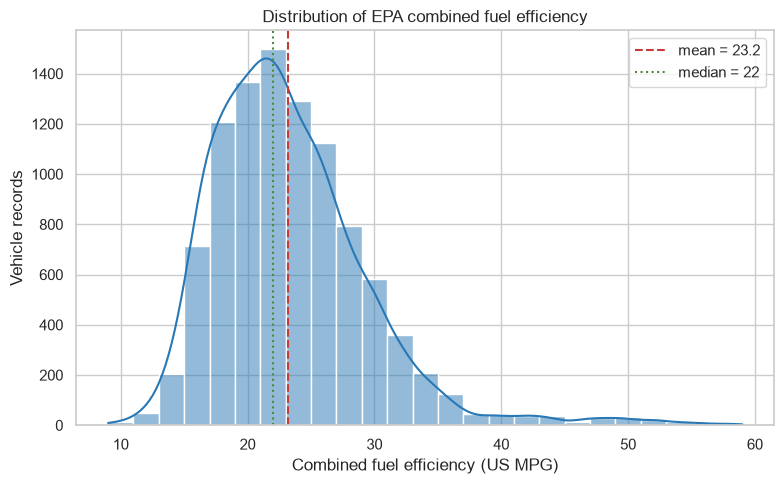

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(train, x='mpg', bins=25, kde=True, color='#2878B5', ax=ax)
ax.axvline(train['mpg'].mean(), color='#C43C39', linestyle='--', label=f"mean = {train['mpg'].mean():.1f}")
ax.axvline(train['mpg'].median(), color='#4B8B3B', linestyle=':', label=f"median = {train['mpg'].median():.0f}")
ax.set(title='Distribution of EPA combined fuel efficiency', xlabel='Combined fuel efficiency (US MPG)', ylabel='Vehicle records')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'eda_target_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

**Interpretation.** MPG ranges from 9 to 59; the median is 22 MPG and the mean is 23.2 MPG. Most vehicles lie around 19--26 MPG, with a thinner upper tail (the 95th percentile is 34 MPG). The target is bounded and somewhat right-skewed, so MAE in MPG is easier to interpret than a percentage error; rare high-MPG cases should still be checked in model error analysis.

## Plot 2 - Engine displacement versus efficiency

Weight is unavailable, so this uses the available engine-size variable (`displacement`, litres).

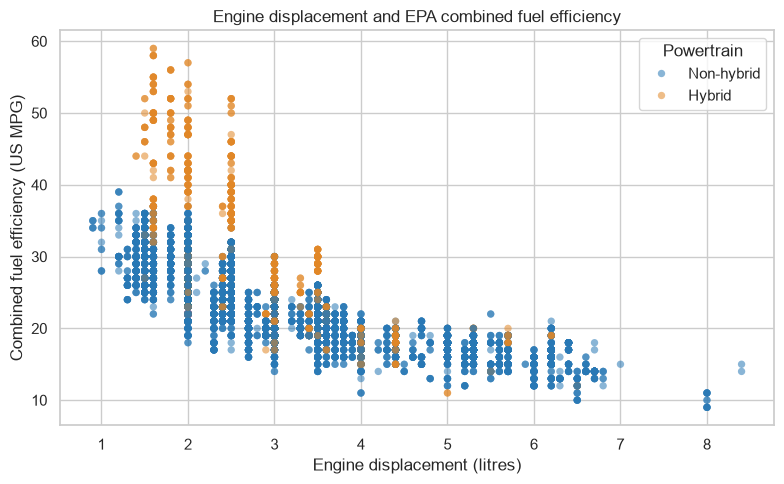

Pearson correlation (displacement, MPG): -0.705


In [4]:
plot_data = train.assign(hybrid_label=train['hybrid'].map({0: 'Non-hybrid', 1: 'Hybrid'}))
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=plot_data, x='displacement', y='mpg', hue='hybrid_label', palette={'Non-hybrid': '#2878B5', 'Hybrid': '#E18727'}, alpha=0.55, s=28, linewidth=0, ax=ax)
ax.set(title='Engine displacement and EPA combined fuel efficiency', xlabel='Engine displacement (litres)', ylabel='Combined fuel efficiency (US MPG)')
ax.legend(title='Powertrain')
fig.tight_layout()
fig.savefig(FIGURES / 'eda_displacement_vs_mpg.png', dpi=160, bbox_inches='tight')
plt.show()
print(f"Pearson correlation (displacement, MPG): {train['displacement'].corr(train['mpg']):.3f}")

**Interpretation.** Displacement has a strong negative linear correlation with MPG (-0.705): larger engines generally have lower fuel efficiency. The scatter has substantial vertical spread at the same displacement, particularly below 3 L, so displacement alone cannot determine MPG. Hybrid vehicles occupy part of the higher-MPG region, which supports retaining technology and categorical specification features rather than using one numeric predictor alone.

## Plot 3 - Efficiency by model year

Horsepower is unavailable, so this plot uses another available requested vehicle characteristic: model year.

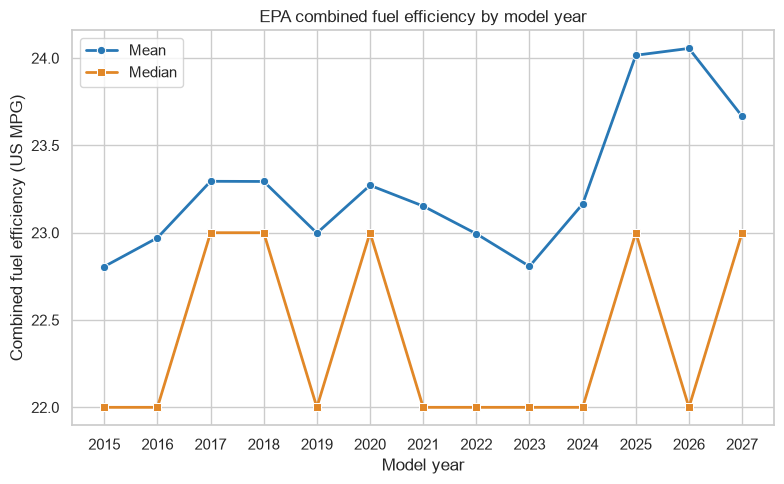

,index,model_year,mean,median,count
0,0,2015,22.806265,22.0,862
1,1,2016,22.970862,22.0,858
2,2,2017,23.294387,23.0,873
3,3,2018,23.293393,23.0,893
4,4,2019,22.997807,22.0,912
5,5,2020,23.271309,23.0,833
6,6,2021,23.152522,22.0,813
7,7,2022,22.993804,22.0,807
8,8,2023,22.807273,22.0,825
9,9,2024,23.164464,22.0,681


In [5]:
yearly = train.groupby('model_year', as_index=False)['mpg'].agg(['mean', 'median', 'count']).reset_index()
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=yearly, x='model_year', y='mean', marker='o', linewidth=2, color='#2878B5', ax=ax, label='Mean')
sns.lineplot(data=yearly, x='model_year', y='median', marker='s', linewidth=2, color='#E18727', ax=ax, label='Median')
ax.set(title='EPA combined fuel efficiency by model year', xlabel='Model year', ylabel='Combined fuel efficiency (US MPG)')
ax.set_xticks(sorted(train['model_year'].unique()))
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'eda_mpg_by_model_year.png', dpi=160, bbox_inches='tight')
plt.show()
display(yearly)

**Interpretation.** Mean MPG is fairly stable across 2015--2024 (about 22.8--23.3), then reaches about 24.0 in 2025--2026; the 2027 group is smaller (261 training rows) and should not be over-interpreted. The overall linear correlation between model year and MPG is only 0.034, so year may add context but is not a strong standalone signal in this filtered sample.

## Plot 4 - Efficiency by cylinder count

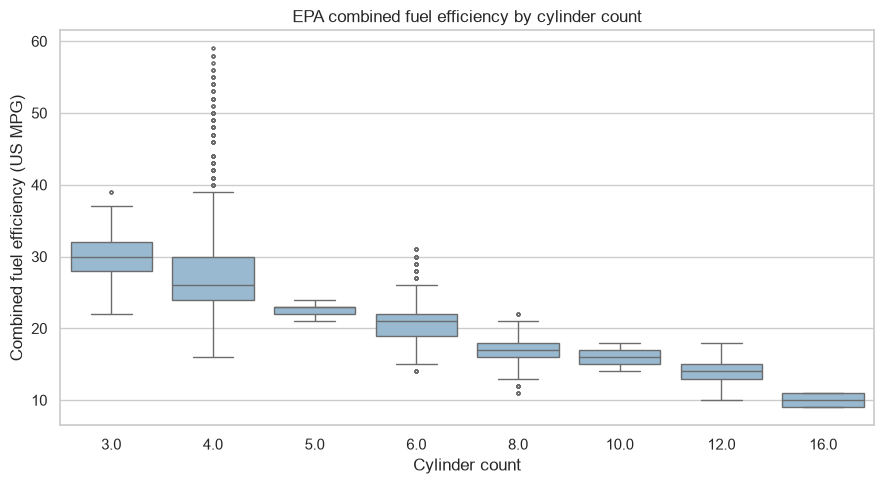

,count,mean,median
cylinders,,,
3.0,172,30.3,30.0
4.0,4389,27.6,26.0
5.0,20,22.5,23.0
6.0,3177,21.0,21.0
8.0,1812,17.1,17.0
10.0,43,15.8,16.0
12.0,191,14.2,14.0
16.0,12,10.0,10.0


In [6]:
order = sorted(train['cylinders'].unique())
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=train, x='cylinders', y='mpg', order=order, color='#8FBBD9', fliersize=2, ax=ax)
ax.set(title='EPA combined fuel efficiency by cylinder count', xlabel='Cylinder count', ylabel='Combined fuel efficiency (US MPG)')
fig.tight_layout()
fig.savefig(FIGURES / 'eda_mpg_by_cylinders.png', dpi=160, bbox_inches='tight')
plt.show()
cylinder_summary = train.groupby('cylinders')['mpg'].agg(['count', 'mean', 'median']).round(1)
display(cylinder_summary)

**Interpretation.** The relationship is strongly ordered: 4-cylinder vehicles average 27.6 MPG, 6-cylinder vehicles 21.0 MPG, and 8-cylinder vehicles 17.1 MPG; cylinder count correlates -0.686 with MPG. Counts for 5, 10, 12, and 16 cylinders are small (20, 43, 191, and 12), so their boxplots are descriptive rather than stable population estimates. Treat cylinder count as a discrete engine characteristic and rely on validation/CV to determine its modelling value.

## Handoff summary

- The four figures are saved under `reports/figures/` when this notebook runs.
- Displacement and cylinders are the strongest simple numeric associations with MPG in the training data; model year alone is weak.
- No missing or invalid values in the project columns require a new cleaning rule. Preserve plausible rare engine configurations.
- No claims here use validation/test data. Model selection, tuning, and final test evaluation remain TODO for the team.